<a href="https://colab.research.google.com/github/mfachriridwan/claude/blob/main/riset_halog!.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)

SEED = 7
rng = np.random.default_rng(SEED)

# Pathway labels
PATHWAYS = {
    1: "WtE",
    2: "RDF",
    3: "AD",
    4: "PHB"
}

print("Libraries loaded.")

Libraries loaded.


In [3]:
# ============================================================
# WASTE FRACTIONS AND PHYSICAL PROPERTIES
# ============================================================

FR = [
    "food",
    "garden",
    "paper",
    "compos",
    "plastic",
    "metal",
    "glass",
    "inert"
]

A = lambda *v: np.array(v, dtype=float)

#                 food  gard  paper compos plastic metal glass inert
DOC  = A(0.15, 0.20, 0.40, 0.24, 0.00, 0.00, 0.00, 0.00)
LDRY = A(17.0, 16.0, 16.0, 19.0, 35.0, 0.0, 0.0, 5.0)
CDRY = A(38.0, 49.0, 46.0, 50.0, 75.0, 0.0, 0.0, 3.0)
PHI  = A(0.00, 0.00, 0.01, 0.20, 1.00, 0.0, 0.0, 1.0)
TAU  = A(0.05, 0.30, 0.80, 0.70, 0.90, 0.0, 0.25, 0.25)

# Moisture content by waste category
w_moisture = A(
    0.65,  # food
    0.55,  # garden
    0.20,  # paper
    0.20,  # composite
    0.10,  # plastic
    0.03,  # metal
    0.02,  # glass
    0.15   # inert
)

print("Waste properties loaded.")

Waste properties loaded.


In [4]:
# ============================================================
# MODEL PARAMETERS
# ============================================================

p = dict(

    # -----------------------
    # Landfill / LCA
    # -----------------------
    GWP_CH4 = 28.0,
    MCF     = 0.80,
    DOC_F   = 0.50,
    F       = 0.50,

    # Latent heat of vaporisation
    LAM     = 2.443,

    # RDF product moisture
    OMEGA   = 0.20,

    # -----------------------
    # WtE
    # -----------------------
    ETA_EL  = 0.22,
    EPS     = 0.15,

    # Indonesia grid factor
    EF_GRID = 0.83,

    # Coal emission factor
    EF_COAL = 94.6,

    # -----------------------
    # Anaerobic Digestion
    # -----------------------
    VS_TS    = 0.85,
    B0       = 0.40,
    F_DEG    = 0.75,
    SIG      = 0.02,
    ETA_CHP  = 0.35,
    EPS_AD   = 0.15,
    RHO_CH4  = 0.716,
    LHV_CH4  = 35.9,

    # -----------------------
    # PHB from methane
    # -----------------------
    ETA_REC      = 0.75,
    R_CH4_PHB    = 2.30,
    EF_PLASTIC   = 3.40,
    EF_PHB_PROC  = 1.43,

    # -----------------------
    # Economic assumptions
    # -----------------------
    AVAIL = 0.85,
    R     = 0.10,
    N     = 30.0,

    Q_REF = 1000.0,

    K_WTE = 102.2e6,
    K_RDF = 18000.0,
    K_AD  = 20000.0,
    K_PHB = 35000.0,

    FIT   = 0.14,
    P_RDF = 19.0,
    P_PHB = 1800.0,
    TIP   = 7.0,

    P_C     = 15.0,
    KAPPA_C = 0.70,

    OPEX_WTE = 0.04,
    OPEX_RDF = 20.5,
    OPEX_AD  = 22.0,
    OPEX_PHB = 900.0,

    C0 = 5.0
)

print("Model parameters loaded.")

Model parameters loaded.


In [5]:
# ============================================================
# CORE PHYSICAL FUNCTIONS
# ============================================================

def norm(x):
    """
    Normalize waste composition so fractions sum to 1.
    """
    x = np.asarray(x, dtype=float)

    total = x.sum(axis=-1, keepdims=True)

    return np.divide(
        x,
        total,
        out=np.zeros_like(x),
        where=total > 0
    )


def L0(s):
    """
    Methane generation potential
    kg CH4 / tonne waste
    """
    s = np.asarray(s)

    return (
        1e3
        * p["MCF"]
        * (s * DOC).sum(axis=-1)
        * p["DOC_F"]
        * p["F"]
        * (16 / 12)
    )


def lhv(s, w):
    """
    Lower heating value of wet MSW
    MJ/kg
    """
    s = np.asarray(s)
    w = np.asarray(w)

    dry_energy = (
        s * LDRY * (1 - w)
    ).sum(axis=-1)

    moisture_penalty = (
        p["LAM"] * (s * w).sum(axis=-1)
    )

    return np.maximum(
        0.0,
        dry_energy - moisture_penalty
    )

In [6]:
# ============================================================
# LCA PATHWAYS
# kg CO2-eq / tonne MSW
# ============================================================

def gwp_S0(s):
    """
    Baseline:
    unmanaged/reference landfill methane.
    """
    return L0(s) * p["GWP_CH4"]


def gwp_S1(s, w):
    """
    S1: Waste-to-Energy
    """

    fossil_CO2 = (
        1e3
        * (
            s
            * (1 - w)
            * (CDRY / 100)
            * PHI
        ).sum(axis=-1)
        * 44 / 12
    )

    # Electricity generated: kWh/t waste
    E = (
        lhv(s, w)
        * p["ETA_EL"]
        * (1 - p["EPS"])
        / 3.6
        * 1e3
    )

    GWP = (
        fossil_CO2
        - E * p["EF_GRID"]
    )

    return GWP, E


def gwp_S2(s, w):
    """
    S2: RDF production and coal substitution.
    """

    fossil_CO2 = (
        1e3
        * (
            s
            * TAU
            * (1 - w)
            * (CDRY / 100)
            * PHI
        ).sum(axis=-1)
        * 44 / 12
    )

    # Dry matter transferred to RDF
    mdm = (
        s
        * TAU
        * (1 - w)
    ).sum(axis=-1)

    # RDF mass
    mrdf = mdm / (1 - p["OMEGA"])

    # RDF NCV
    ncv = (
        (
            s
            * TAU
            * (1 - w)
            * LDRY
        ).sum(axis=-1)
        / np.maximum(mdm, 1e-12)
        * (1 - p["OMEGA"])
        - p["LAM"] * p["OMEGA"]
    )

    # Reject fraction
    reject = np.maximum(
        0.0,
        1 - (s * TAU).sum(axis=-1)
    )

    reject_composition = norm(
        s * (1 - TAU)
    )

    reject_GWP = (
        reject
        * L0(reject_composition)
        * p["GWP_CH4"]
    )

    coal_credit = (
        mrdf
        * ncv
        * p["EF_COAL"]
    )

    GWP = (
        fossil_CO2
        + reject_GWP
        - coal_credit
    )

    return GWP, mrdf, ncv


def gwp_S3(s, w):
    """
    S3: Anaerobic digestion of food waste.
    """

    food = s[..., 0]

    methane_volume = (
        food
        * (1 - w[..., 0])
        * p["VS_TS"]
        * p["B0"]
        * p["F_DEG"]
        * 1e3
    )

    E = (
        methane_volume
        * p["LHV_CH4"]
        * (1 - p["SIG"])
        * p["ETA_CHP"]
        * (1 - p["EPS_AD"])
        / 3.6
    )

    methane_leak = (
        p["SIG"]
        * methane_volume
        * p["RHO_CH4"]
        * p["GWP_CH4"]
    )

    residual_fraction = 1 - food

    non_food = s * (1 - np.eye(8)[0])

    residual_GWP = (
        residual_fraction
        * L0(norm(non_food))
        * p["GWP_CH4"]
    )

    electricity_credit = (
        E * p["EF_GRID"]
    )

    GWP = (
        methane_leak
        + residual_GWP
        - electricity_credit
    )

    return GWP, E


def gwp_S4(s):
    """
    S4: PHB production from recovered methane.
    """

    methane = L0(s)

    methane_recovered = (
        p["ETA_REC"] * methane
    )

    phb_mass = (
        methane_recovered
        / p["R_CH4_PHB"]
    )

    unrecovered_CH4 = (
        (1 - p["ETA_REC"])
        * methane
        * p["GWP_CH4"]
    )

    PHB_processing = (
        phb_mass
        * p["EF_PHB_PROC"]
    )

    plastic_credit = (
        phb_mass
        * p["EF_PLASTIC"]
    )

    GWP = (
        unrecovered_CH4
        + PHB_processing
        - plastic_credit
    )

    return GWP, phb_mass

In [7]:
# ============================================================
# TECHNO-ECONOMIC ASSESSMENT
# ============================================================

def annuity_factor():
    return (
        1 - (1 + p["R"]) ** (-p["N"])
    ) / p["R"]


def tea(K, O, R_rev, dG, Q):
    """
    Techno-economic indicators.

    K     : CAPEX
    O     : annual OPEX
    R_rev : annual revenue
    dG    : avoided GWP, kg CO2e/t
    Q     : t/day
    """

    a = annuity_factor()

    annual_waste = (
        Q * 365 * p["AVAIL"]
    )

    NPV = (
        -K
        + (R_rev - O) * a
    ) / 1e6

    LCOT = (
        K / a + O
    ) / np.maximum(
        annual_waste,
        1e-9
    )

    MAC = (
        K / a
        + O
        - p["C0"] * annual_waste
    ) / np.maximum(
        dG * annual_waste / 1e3,
        1e-9
    )

    return {
        "NPV": NPV,
        "LCOT": LCOT,
        "MAC": MAC
    }

In [9]:
# ============================================================
# COMPLETE PATHWAY EVALUATION
# ============================================================

def evaluate(s, w, Q):

    s = np.atleast_2d(s)
    w = np.atleast_2d(w)
    Q = np.atleast_1d(Q).astype(float)

    annual_waste = (
        Q * 365 * p["AVAIL"]
    )

    # -----------------------
    # LCA
    # -----------------------

    G0 = gwp_S0(s)

    G1, E_wte = gwp_S1(s, w)

    G2, m_rdf, ncv = gwp_S2(s, w)

    G3, E_ad = gwp_S3(s, w)

    G4, m_phb = gwp_S4(s)

    G = {
        1: G1,
        2: G2,
        3: G3,
        4: G4
    }

    dG = {
        k: G0 - G[k]
        for k in G
    }

    # -----------------------
    # CAPEX
    # -----------------------

    K = {

        1:
        p["K_WTE"]
        * (Q / p["Q_REF"]) ** 0.6,

        2:
        p["K_RDF"] * Q,

        3:
        p["K_AD"] * Q,

        4:
        p["K_PHB"] * Q
    }

    # -----------------------
    # OPEX
    # -----------------------

    O = {

        1:
        p["OPEX_WTE"] * K[1],

        2:
        p["OPEX_RDF"] * annual_waste,

        3:
        p["OPEX_AD"] * annual_waste,

        4:
        p["OPEX_PHB"]
        * (m_phb * annual_waste / 1e3)
    }

    # -----------------------
    # Revenue
    # -----------------------

    Rev = {

        1:
        E_wte
        * annual_waste
        * p["FIT"]
        +
        dG[1]
        / 1e3
        * annual_waste
        * p["P_C"]
        * p["KAPPA_C"],

        2:
        m_rdf
        * annual_waste
        * p["P_RDF"]
        +
        p["TIP"]
        * annual_waste,

        3:
        E_ad
        * annual_waste
        * p["FIT"]
        +
        p["TIP"]
        * annual_waste,

        4:
        (
            m_phb
            * annual_waste
            / 1e3
        )
        * p["P_PHB"]
        +
        dG[4]
        / 1e3
        * annual_waste
        * p["P_C"]
        * p["KAPPA_C"]
    }

    # -----------------------
    # TEA results
    # -----------------------

    out = {}

    for k in (1, 2, 3, 4):

        economic = tea(
            K[k],
            O[k],
            Rev[k],
            dG[k],
            Q
        )

        out[k] = {
            "GWP": G[k],
            "dGWP": dG[k],
            **economic
        }

    characteristics = {

        "LHV": lhv(s, w),

        "NCV": ncv,

        "mRDF": m_rdf,

        "mPHB": m_phb,

        "E_WTE": E_wte,

        "E_AD": E_ad
    }

    return G0, out, characteristics

In [10]:
# ============================================================
# TECHNOLOGY FACTOR FUNCTIONS
# ============================================================

def inc(x, low, high):

    x = np.asarray(x, dtype=float)

    return np.clip(
        (x - low)
        / max(high - low, 1e-12),
        0.0,
        1.0
    )


def dec(x, good, maximum):

    x = np.asarray(x, dtype=float)

    return (
        1.0
        - np.clip(
            (x - good)
            / max(maximum - good, 1e-12),
            0.0,
            1.0
        )
    )


def technology_factor(
    s,
    w,
    Q,
    ncv=None,
    phb_maturity=None
):

    s = np.atleast_2d(s)
    w = np.atleast_2d(w)

    # ========================================================
    # Waste characteristics
    # ========================================================

    LHV = lhv(s, w)

    food = s[:, 0]

    methane_potential = L0(s)

    # ========================================================
    # 1. WtE
    # ========================================================

    TF_WTE = inc(
        LHV,
        TF_PAR["WTE"]["LHV_min"],
        TF_PAR["WTE"]["LHV_good"]
    )

    # ========================================================
    # 2. RDF
    # ========================================================

    if ncv is None:

        _, _, ncv = gwp_S2(
            s,
            w
        )

    rdf_energy = inc(
        ncv,
        TF_PAR["RDF"]["NCV_min"],
        TF_PAR["RDF"]["NCV_good"]
    )

    rdf_moisture = dec(
        p["OMEGA"],
        TF_PAR["RDF"]["MC_good"],
        TF_PAR["RDF"]["MC_max"]
    )

    TF_RDF = np.sqrt(
        np.maximum(
            rdf_energy,
            1e-12
        )
        *
        np.maximum(
            rdf_moisture,
            1e-12
        )
    )

    # ========================================================
    # 3. AD
    # ========================================================

    gamma = TF_PAR["AD"]["gamma"]

    TF_AD = np.clip(
        food ** gamma,
        0.0,
        1.0
    )

    # ========================================================
    # 4. PHB
    # ========================================================

    K_CH4 = TF_PAR["PHB"]["CH4_half"]

    methane_score = (
        methane_potential
        /
        (
            methane_potential
            + K_CH4
        )
    )

    if phb_maturity is None:

        phb_maturity = (
            TF_PAR["PHB"]["maturity"]
        )

    TF_PHB = (
        methane_score
        * phb_maturity
    )

    return {

        1: TF_WTE,
        2: TF_RDF,
        3: TF_AD,
        4: TF_PHB
    }

In [11]:
# ============================================================
# UNIFIED DESIRABILITY MODEL
# ============================================================

def desirability(
    out,
    TF,
    wG=0.625,
    wE=0.375
):

    ks = [1, 2, 3, 4]

    # Higher avoided GWP = better
    dG = np.array([
        out[k]["dGWP"]
        for k in ks
    ])

    # Higher NPV = better
    npv = np.array([
        out[k]["NPV"]
        for k in ks
    ])

    def benefit_normalize(x):

        xmin = x.min(
            axis=0
        )

        xmax = x.max(
            axis=0
        )

        return (
            (x - xmin)
            /
            np.maximum(
                xmax - xmin,
                1e-9
            )
        )

    environmental = benefit_normalize(
        dG
    )

    economic = benefit_normalize(
        npv
    )

    performance = (
        wG * environmental
        +
        wE * economic
    )

    TF_array = np.array([
        TF[k]
        for k in ks
    ])

    D = (
        TF_array
        * performance
    )

    return dict(
        zip(
            ks,
            D
        )
    )

In [12]:
# ============================================================
# LOAD INPUT DATA
# ============================================================

from google.colab import files

uploaded = files.upload()

df_input = pd.read_csv(
    "input_kota.csv"
)

print(
    "Number of locations:",
    len(df_input)
)

display(
    df_input.head()
)

Saving input_kota.csv to input_kota (1).csv
Number of locations: 6


,city_id,city_name,admin_level,province,year_base,M_dom_tpd,M_nd_tpd,growth,composition_mode,dom_sisa_makanan,dom_daun_kering,dom_kertas_kardus,dom_kayu,dom_plastik,dom_logam,dom_kain,dom_karet_kulit,dom_sterofoam,dom_b3,dom_elektronik,dom_lain_lain,nd_sisa_makanan,nd_daun_kering,nd_kertas_kardus,nd_kayu,nd_plastik,nd_logam,nd_kain,nd_karet_kulit,nd_sterofoam,nd_b3,nd_elektronik,nd_lain_lain,dom_kaca,nd_kaca,glass_folded_into_inert,organik_lumped_to_food,source_pdf,source_pages,kode_wilayah,horizon_year,population_base,per_capita_kg_d,lat,lon,coord_type,anchors_json,managed_share,rips_status,existing_facilities,notes,M_total_tpd,x_Cl,x_S
0,kota_padang,Kota Padang,kota,Sumatera Barat,2023,620.73,26.84,0.0065,separate,43.95,15.68,8.85,0.42,19.84,1.30,1.80,0.27,0.22,0.18,1.09,6.41,51.56,25.78,6.34,0.26,9.61,1.36,0.93,0.26,0.54,0.33,0.17,2.85,NaN,NaN,False,False,RIPS extract (author),RIPS Kota Padang (komposisi domestik/non-domes...,13.71,2044,NaN,NaN,-0.9492,100.3543,centroid,NaN,NaN,NaN,NaN,12 categories; kaca not folded in this extract...,647.57,NaN,NaN
1,kab_bogor,Kab. Bogor,kabupaten,Jawa Barat,2022,1875.26,806.31,0.0254,combined,55.30,2.26,7.60,0.00,16.57,1.13,2.70,0.12,0.00,0.00,0.00,14.31,55.30,2.26,7.60,0.00,16.57,1.13,2.70,0.12,0.00,0.00,0.00,14.31,NaN,NaN,True,False,RIPS extract (author),Gambar 3.7; Tabel 3.12 p.77; Tabel 4.5 p.145,32.01,2045,NaN,NaN,-6.5944,106.7892,centroid,NaN,NaN,NaN,NaN,Single composition copied to dom and nd; kaca ...,2681.57,NaN,NaN
2,kab_serang,Kab. Serang,kabupaten,Banten,2024,849.00,317.00,0.0180,separate,49.52,12.15,2.10,0.00,28.07,0.00,0.96,0.00,1.35,0.10,0.00,5.74,47.20,0.00,15.54,0.98,14.94,0.55,0.85,0.12,0.00,0.96,0.00,18.86,NaN,NaN,True,False,RIPS extract (author),RIPS Kab. Serang (dom & nd terpisah),36.04,2034,NaN,NaN,-6.1200,106.1500,centroid,NaN,NaN,NaN,NaN,kaca dom 0.16 and nd 1.26 folded into lain_lai...,1166.00,NaN,NaN
3,kota_denpasar,Kota Denpasar,kota,Bali,2023,718.44,168.54,0.0176,combined,26.28,43.38,8.26,0.00,11.10,2.91,1.04,3.09,0.27,0.00,0.00,3.67,26.28,43.38,8.26,0.00,11.10,2.91,1.04,3.09,0.27,0.00,0.00,3.67,NaN,NaN,True,False,RIPS extract (author),Tabel 3.29,51.71,2044,NaN,NaN,-8.6705,115.2126,centroid,NaN,NaN,NaN,NaN,Combined composition; kaca 1.94 + keramik 0.06...,886.98,NaN,NaN
4,kab_cianjur,Kab. Cianjur,kabupaten,Jawa Barat,2023,828.63,248.36,0.0169,combined,61.05,0.00,6.94,1.04,14.39,0.14,2.10,0.50,0.00,0.11,0.00,13.72,61.05,0.00,6.94,1.04,14.39,0.14,2.10,0.50,0.00,0.11,0.00,13.72,NaN,NaN,True,True,RIPS extract (author),Gambar 3-16,32.03,2043,NaN,NaN,-6.8170,107.1425,centroid,NaN,NaN,NaN,NaN,organik 61.05 lumped to sisa_makanan; kaca 1.4...,1076.99,NaN,NaN


In [13]:
# ============================================================
# MAP ORIGINAL CATEGORIES TO MODEL FRACTIONS
# ============================================================

MAP = {

    "food": [
        "sisa_makanan"
    ],

    "garden": [
        "daun_kering",
        "kayu"
    ],

    "paper": [
        "kertas_kardus"
    ],

    "compos": [
        "kain",
        "karet_kulit",
        "elektronik"
    ],

    "plastic": [
        "plastik",
        "sterofoam"
    ],

    "metal": [
        "logam"
    ],

    "glass": [
        "kaca"
    ],

    "inert": [
        "b3",
        "lain_lain"
    ]
}


def macro(row, prefix):

    values = []

    for fraction in FR:

        total = 0.0

        for category in MAP[fraction]:

            column = (
                f"{prefix}_{category}"
            )

            value = row.get(
                column,
                np.nan
            )

            if not pd.isna(value):
                total += float(value)

        values.append(total)

    values = np.array(
        values,
        dtype=float
    )

    if values.sum() > 0:

        values = (
            values
            / values.sum()
        )

    return values

In [14]:
# ============================================================
# BUILD CITY COMPOSITION MATRIX
# ============================================================

S_composition = []

for _, r in df_input.iterrows():

    md = float(r.M_dom_tpd)
    mn = float(r.M_nd_tpd)

    total_source = md + mn

    if total_source > 0:

        wd = (
            md / total_source
        )

    else:

        wd = 0.5

    s_dom = macro(
        r,
        "dom"
    )

    s_nd = macro(
        r,
        "nd"
    )

    s = (
        wd * s_dom
        +
        (1 - wd) * s_nd
    )

    s = norm(
        s[None, :]
    )[0]

    S_composition.append(
        s
    )


S_composition = np.array(
    S_composition
)

composition_df = pd.DataFrame(
    S_composition,
    columns=FR
)

composition_df.insert(
    0,
    "city_name",
    df_input.city_name.values
)

display(
    composition_df
)

,city_name,food,garden,paper,compos,plastic,metal,glass,inert
0,Kota Padang,0.442614,0.165106,0.087451,0.030851,0.196474,0.013024,0.0,0.064480
1,Kab. Bogor,0.553055,0.022602,0.076008,0.028203,0.165717,0.011301,0.0,0.143114
2,Kab. Serang,0.488929,0.091141,0.057541,0.009628,0.254855,0.001495,0.0,0.096412
3,Kota Denpasar,0.262800,0.433800,0.082600,0.041300,0.113700,0.029100,0.0,0.036700
4,Kab. Cianjur,0.610561,0.010401,0.069407,0.026003,0.143914,0.001400,0.0,0.138314
5,Kab. Indramayu,0.602240,0.005699,0.084692,0.016998,0.137786,0.001600,0.0,0.150985


In [17]:
# ============================================================
# DETERMINISTIC CITY ANALYSIS
# ============================================================

# Default Technology Factor Parameters (TF_PAR)
# These are example values; adjust as necessary.
TF_PAR = {
    "WTE": {
        "LHV_min": 5.0,   # MJ/kg
        "LHV_good": 10.0 # MJ/kg
    },
    "RDF": {
        "NCV_min": 10.0,  # MJ/kg
        "NCV_good": 15.0, # MJ/kg
        "MC_good": 0.15,  # Moisture Content good
        "MC_max": 0.30    # Moisture Content max
    },
    "AD": {
        "gamma": 0.5      # exponent for food content
    },
    "PHB": {
        "CH4_half": 50.0, # kg CH4 / tonne waste (half-saturation constant)
        "maturity": 0.75  # Maturity factor for PHB technology
    }
}

rows = []

for i, r in df_input.iterrows():

    s = S_composition[i]

    Q = float(
        r.M_total_tpd
    )

    # LCA + TEA
    G0, out, ch = evaluate(

        s[None, :],

        w_moisture[None, :],

        np.array([Q])
    )

    # Technology feasibility
    TF = technology_factor(

        s[None, :],

        w_moisture[None, :],

        np.array([Q]),

        ncv=ch["NCV"]
    )

    # Integrated score
    D = desirability(
        out,
        TF
    )

    best_id = max(
        D,
        key=lambda k: D[k][0]
    )

    rows.append({

        "city_name":
            r.city_name,

        "admin_level":
            r.admin_level,

        "Q_tpd":
            Q,

        "food_pct":
            100 * s[0],

        "garden_pct":
            100 * s[1],

        "paper_pct":
            100 * s[2],

        "plastic_pct":
            100 * s[4],

        "LHV_MJkg":
            ch["LHV"][0],

        "RDF_NCV_MJkg":
            ch["NCV"][0],

        "L0_kgCH4_t":
            L0(s[None, :])[0],

        "G0_kgCO2e_t":
            G0[0],

        # -------------------
        # Avoided GWP
        # -------------------

        "dGWP_WtE":
            out[1]["dGWP"][0],

        "dGWP_RDF":
            out[2]["dGWP"][0],

        "dGWP_AD":
            out[3]["dGWP"][0],

        "dGWP_PHB":
            out[4]["dGWP"][0],

        # -------------------
        # NPV
        # -------------------

        "NPV_WtE_MUSD":
            out[1]["NPV"][0],

        "NPV_RDF_MUSD":
            out[2]["NPV"][0],

        "NPV_AD_MUSD":
            out[3]["NPV"][0],

        "NPV_PHB_MUSD":
            out[4]["NPV"][0],

        # -------------------
        # Technology Factor
        # -------------------

        "TF_WtE":
            TF[1][0],

        "TF_RDF":
            TF[2][0],

        "TF_AD":
            TF[3][0],

        "TF_PHB":
            TF[4][0],

        # -------------------
        # Desirability
        # -------------------

        "D_WtE":
            D[1][0],

        "D_RDF":
            D[2][0],

        "D_AD":
            D[3][0],

        "D_PHB":
            D[4][0],

        "best_pathway":
            PATHWAYS[best_id]
    })


df_results = pd.DataFrame(
    rows
)

display(
    df_results.round(3)
)

,city_name,admin_level,Q_tpd,food_pct,garden_pct,paper_pct,plastic_pct,LHV_MJkg,RDF_NCV_MJkg,L0_kgCH4_t,G0_kgCO2e_t,dGWP_WtE,dGWP_RDF,dGWP_AD,dGWP_PHB,NPV_WtE_MUSD,NPV_RDF_MUSD,NPV_AD_MUSD,NPV_PHB_MUSD,TF_WtE,TF_RDF,TF_AD,TF_PHB,D_WtE,D_RDF,D_AD,D_PHB,best_pathway
0,Kota Padang,kota,647.57,44.261,16.511,8.745,19.647,10.819,20.808,37.813,1058.759,1022.656,579.386,575.216,818.360,60.905,-24.804,-10.907,14.627,1.000,0.816,0.665,0.323,1.000,0.005,0.040,0.165,WtE
1,Kab. Bogor,kabupaten,2681.57,55.306,2.260,7.601,16.572,9.630,19.831,33.240,930.723,913.084,446.042,718.744,719.396,370.080,-109.105,-13.701,41.895,0.926,0.816,0.744,0.299,0.926,0.000,0.327,0.145,WtE
2,Kab. Serang,kabupaten,1166.00,48.893,9.114,5.754,25.485,11.857,22.578,31.172,872.812,740.612,419.479,635.406,674.634,166.235,-43.538,-13.902,14.544,1.000,0.816,0.699,0.288,1.000,0.000,0.331,0.173,WtE
3,Kota Denpasar,kota,886.98,26.280,43.380,8.260,11.370,9.006,18.128,45.102,1262.852,1353.046,707.161,341.532,976.112,75.780,-36.259,-31.886,29.881,0.801,0.816,0.513,0.356,0.801,0.184,0.008,0.218,WtE
4,Kab. Cianjur,kabupaten,1076.99,61.056,1.040,6.941,14.391,8.996,19.484,34.045,953.253,963.439,407.459,793.477,736.810,90.800,-45.673,1.078,18.146,0.799,0.816,0.781,0.304,0.799,0.000,0.439,0.166,WtE
5,Kab. Indramayu,kabupaten,1126.29,60.224,0.570,8.469,13.779,8.846,18.920,34.515,966.426,986.543,434.438,782.663,746.992,94.882,-47.632,0.131,19.784,0.769,0.816,0.776,0.306,0.769,0.000,0.403,0.163,WtE


In [21]:
df_results.to_csv(
    "hasil_6kota_TF.csv",
    index=False
)

df_results.to_excel(
    "hasil_6kota_TF.xlsx",
    index=False
)

print(
    "Saved: hasil_6kota_TF.csv"
)

print(
    "Saved: hasil_6kota_TF.xlsx"
)

Saved: hasil_6kota_TF.csv
Saved: hasil_6kota_TF.xlsx


In [22]:
# ============================================================
# ANALYTICAL COMPOSITION UNCERTAINTY
# ============================================================

def dir_var_linear(
    g,
    sbar,
    alpha0
):

    return (
        np.sum(
            g**2 * sbar
        )
        -
        (
            np.sum(
                g * sbar
            )
        )**2
    ) / (
        alpha0 + 1
    )


def characterise_uncertainty(
    sbar,
    w,
    alpha0
):

    # L0 coefficient
    kL = (
        1e3
        * p["MCF"]
        * p["DOC_F"]
        * p["F"]
        * (16 / 12)
    )

    gL = (
        kL * DOC
    )

    sd_L0 = np.sqrt(
        dir_var_linear(
            gL,
            sbar,
            alpha0
        )
    )

    # LHV coefficient
    gH = (
        LDRY * (1 - w)
        - p["LAM"] * w
    )

    sd_LHV = np.sqrt(
        dir_var_linear(
            gH,
            sbar,
            alpha0
        )
    )

    L0_mean = (
        kL
        * np.sum(
            sbar * DOC
        )
    )

    LHV_mean = max(
        0.0,
        np.sum(
            sbar
            * LDRY
            * (1 - w)
        )
        -
        p["LAM"]
        * np.sum(
            sbar * w
        )
    )

    sd_fraction = np.sqrt(
        sbar
        * (1 - sbar)
        / (alpha0 + 1)
    )

    return {

        "L0":
            (L0_mean, sd_L0),

        "LHV":
            (LHV_mean, sd_LHV),

        "G0":
            (
                L0_mean
                * p["GWP_CH4"],

                sd_L0
                * p["GWP_CH4"]
            ),

        "sd_fraction":
            sd_fraction
    }

In [20]:
# ============================================================
# MONTE CARLO ENGINE
# ============================================================

def mc_pathways(
    sbar,
    w,
    Q,
    alpha0=80,
    N=10000,
    seed=1,
    phb_price_cv=0.25,
    uncertain_phb_maturity=True
):

    rng = np.random.default_rng(
        seed
    )

    # Avoid zero Dirichlet parameters
    sbar_positive = np.maximum(
        sbar,
        1e-9
    )

    sbar_positive /= (
        sbar_positive.sum()
    )

    # Composition uncertainty
    S = rng.dirichlet(
        alpha0 * sbar_positive,
        N
    )

    W = np.tile(
        w,
        (N, 1)
    )

    Q_mc = np.full(
        N,
        Q
    )

    # Save original PHB price
    P_PHB_original = p["P_PHB"]

    # ========================================================
    # PHB price uncertainty
    # ========================================================

    price_multiplier = np.exp(
        rng.normal(
            0,
            phb_price_cv,
            N
        )
    )

    # evaluate() currently expects global scalar P_PHB.
    # Therefore first run physical calculations normally.
    G0, out, ch = evaluate(
        S,
        W,
        Q_mc
    )

    # ========================================================
    # PHB maturity uncertainty
    # ========================================================

    if uncertain_phb_maturity:

        maturity = rng.triangular(
            0.20,
            0.40,
            0.70,
            N
        )

    else:

        maturity = np.full(
            N,
            TF_PAR["PHB"]["maturity"]
        )

    TF = technology_factor(
        S,
        W,
        Q_mc,
        ncv=ch["NCV"],
        phb_maturity=maturity
    )

    # ========================================================
    # Recalculate PHB NPV with sampled PHB prices
    # ========================================================

    annual_waste = (
        Q_mc
        * 365
        * p["AVAIL"]
    )

    mphb = ch["mPHB"]

    K4 = (
        p["K_PHB"]
        * Q_mc
    )

    O4 = (
        p["OPEX_PHB"]
        * mphb
        * annual_waste
        / 1e3
    )

    sampled_PHB_price = (
        P_PHB_original
        * price_multiplier
    )

    Rev4 = (
        mphb
        * annual_waste
        / 1e3
        * sampled_PHB_price
        +
        out[4]["dGWP"]
        / 1e3
        * annual_waste
        * p["P_C"]
        * p["KAPPA_C"]
    )

    tea4 = tea(
        K4,
        O4,
        Rev4,
        out[4]["dGWP"],
        Q_mc
    )

    out[4]["NPV"] = tea4["NPV"]
    out[4]["LCOT"] = tea4["LCOT"]
    out[4]["MAC"] = tea4["MAC"]

    # ========================================================
    # Integrated desirability
    # ========================================================

    D = desirability(
        out,
        TF
    )

    return {

        "composition": S,

        "G0": G0,

        "out": out,

        "characteristics": ch,

        "TF": TF,

        "D": D,

        "PHB_maturity": maturity,

        "PHB_price": sampled_PHB_price
    }

In [23]:
# ============================================================
# CITY-LEVEL MONTE CARLO
# ============================================================

N_MC = 10000
ALPHA0 = 80

uncertainty_results = []

mc_city_results = {}

for i, r in df_input.iterrows():

    city = r.city_name

    s = S_composition[i]

    Q = float(
        r.M_total_tpd
    )

    # Analytical uncertainty
    u = characterise_uncertainty(
        s,
        w_moisture,
        ALPHA0
    )

    # Monte Carlo
    mc = mc_pathways(

        sbar=s,

        w=w_moisture,

        Q=Q,

        alpha0=ALPHA0,

        N=N_MC,

        seed=SEED + i,

        phb_price_cv=0.25,

        uncertain_phb_maturity=True
    )

    mc_city_results[city] = mc

    city_data = {

        "city_name":
            city,

        "L0_mean":
            u["L0"][0],

        "L0_std":
            u["L0"][1],

        "LHV_mean":
            u["LHV"][0],

        "LHV_std":
            u["LHV"][1],

        "G0_mean":
            u["G0"][0],

        "G0_std":
            u["G0"][1]
    }

    # ========================================================
    # Pathway statistics
    # ========================================================

    for k in (1, 2, 3, 4):

        name = PATHWAYS[k]

        npv = mc["out"][k]["NPV"]

        dG = mc["out"][k]["dGWP"]

        tf = mc["TF"][k]

        score = mc["D"][k]

        city_data[
            f"{name}_NPV_p5"
        ] = np.percentile(
            npv,
            5
        )

        city_data[
            f"{name}_NPV_p50"
        ] = np.percentile(
            npv,
            50
        )

        city_data[
            f"{name}_NPV_p95"
        ] = np.percentile(
            npv,
            95
        )

        city_data[
            f"{name}_P_NPV_gt0"
        ] = (
            npv > 0
        ).mean()

        city_data[
            f"{name}_dGWP_p50"
        ] = np.percentile(
            dG,
            50
        )

        city_data[
            f"{name}_TF_p50"
        ] = np.percentile(
            tf,
            50
        )

        city_data[
            f"{name}_D_p50"
        ] = np.percentile(
            score,
            50
        )

    # ========================================================
    # Probability of best pathway
    # ========================================================

    D_matrix = np.vstack([

        mc["D"][1],
        mc["D"][2],
        mc["D"][3],
        mc["D"][4]
    ])

    best = np.argmax(
        D_matrix,
        axis=0
    )

    for j, k in enumerate(
        (1, 2, 3, 4)
    ):

        city_data[
            f"P_best_{PATHWAYS[k]}"
        ] = (
            best == j
        ).mean()

    uncertainty_results.append(
        city_data
    )


df_uncertainty = pd.DataFrame(
    uncertainty_results
)

display(
    df_uncertainty.round(3)
)

,city_name,L0_mean,L0_std,LHV_mean,LHV_std,G0_mean,G0_std,WtE_NPV_p5,WtE_NPV_p50,WtE_NPV_p95,WtE_P_NPV_gt0,WtE_dGWP_p50,WtE_TF_p50,WtE_D_p50,RDF_NPV_p5,RDF_NPV_p50,RDF_NPV_p95,RDF_P_NPV_gt0,RDF_dGWP_p50,RDF_TF_p50,RDF_D_p50,AD_NPV_p5,AD_NPV_p50,AD_NPV_p95,AD_P_NPV_gt0,AD_dGWP_p50,AD_TF_p50,AD_D_p50,PHB_NPV_p5,PHB_NPV_p50,PHB_NPV_p95,PHB_P_NPV_gt0,PHB_dGWP_p50,PHB_TF_p50,PHB_D_p50,P_best_WtE,P_best_RDF,P_best_AD,P_best_PHB
0,Kota Padang,37.813,3.276,10.819,1.165,1058.759,91.732,38.191,60.393,85.234,1.0,1024.228,1.000,1.000,-27.377,-24.854,-22.092,0.0,572.135,0.816,0.000,-17.032,-10.951,-4.730,0.002,574.382,0.665,0.054,0.018,14.541,37.278,0.950,817.524,0.183,0.102,1.000,0.0,0.000,0.0
1,Kab. Bogor,33.240,3.191,9.630,1.112,930.723,89.338,280.385,365.771,468.290,1.0,915.620,0.907,0.900,-119.373,-109.467,-98.303,0.0,434.765,0.816,0.000,-39.772,-13.102,12.193,0.198,721.476,0.745,0.346,-11.990,41.933,124.755,0.887,717.739,0.170,0.084,0.991,0.0,0.009,0.0
2,Kab. Serang,31.172,3.071,11.857,1.282,872.812,85.991,121.492,165.813,213.172,1.0,741.991,1.000,1.000,-48.382,-43.571,-38.457,0.0,410.167,0.816,0.000,-25.157,-13.960,-2.804,0.021,634.797,0.699,0.344,-7.454,14.219,48.721,0.836,673.266,0.162,0.097,0.997,0.0,0.003,0.0
3,Kota Denpasar,45.102,3.000,9.006,0.942,1262.852,84.011,50.035,74.615,104.100,1.0,1356.639,0.786,0.785,-39.229,-36.365,-33.030,0.0,700.044,0.816,0.183,-39.208,-32.093,-23.738,0.000,338.668,0.510,0.007,6.106,29.845,66.249,0.987,975.746,0.202,0.126,1.000,0.0,0.000,0.0
4,Kab. Cianjur,34.045,3.030,8.996,1.053,953.253,84.839,56.856,90.115,128.839,1.0,963.453,0.790,0.789,-49.577,-45.708,-41.472,0.0,397.318,0.816,0.000,-9.340,1.037,11.173,0.565,793.019,0.781,0.459,-3.654,17.569,52.141,0.899,734.882,0.172,0.095,0.906,0.0,0.094,0.0
5,Kab. Indramayu,34.515,3.185,8.846,1.035,966.426,89.182,60.017,93.988,134.052,1.0,986.663,0.758,0.757,-51.682,-47.676,-43.218,0.0,425.666,0.816,0.000,-10.729,0.083,10.621,0.505,782.140,0.776,0.420,-3.753,19.246,55.156,0.909,744.988,0.173,0.093,0.911,0.0,0.089,0.0


In [24]:
df_uncertainty.to_excel(
    "uncertainty_analysis_results.xlsx",
    index=False
)

df_uncertainty.to_csv(
    "uncertainty_analysis_results.csv",
    index=False
)

print(
    "Monte Carlo uncertainty analysis saved."
)

Monte Carlo uncertainty analysis saved.


In [25]:
# ============================================================
# PROBABILITY OF BEST PATHWAY
# ============================================================

best_cols = [

    "city_name",

    "P_best_WtE",

    "P_best_RDF",

    "P_best_AD",

    "P_best_PHB"
]

df_best_probability = (
    df_uncertainty[
        best_cols
    ].copy()
)

display(
    df_best_probability.round(3)
)

,city_name,P_best_WtE,P_best_RDF,P_best_AD,P_best_PHB
0,Kota Padang,1.000,0.0,0.000,0.0
1,Kab. Bogor,0.991,0.0,0.009,0.0
2,Kab. Serang,0.997,0.0,0.003,0.0
3,Kota Denpasar,1.000,0.0,0.000,0.0
4,Kab. Cianjur,0.906,0.0,0.094,0.0
5,Kab. Indramayu,0.911,0.0,0.089,0.0


In [26]:
# ============================================================
# ADMINISTRATIVE-CLASS MONTE CARLO
# ============================================================

class_results = []

for kls in [
    "kota",
    "kabupaten"
]:

    idx = (
        df_input.admin_level
        == kls
    ).values

    if idx.sum() == 0:
        continue

    sbar = (
        S_composition[idx]
        .mean(axis=0)
    )

    sbar = (
        sbar
        / sbar.sum()
    )

    # Method-of-moments approximation
    within = (
        S_composition[idx]
        .var(axis=0)
        .mean()
    )

    alpha0 = max(

        5.0,

        (
            sbar
            * (1 - sbar)
        ).mean()
        /
        max(
            within,
            1e-6
        )
        - 1
    )

    Qbar = (
        df_input.loc[
            idx,
            "M_total_tpd"
        ].mean()
    )

    mc = mc_pathways(

        sbar=sbar,

        w=w_moisture,

        Q=Qbar,

        alpha0=alpha0,

        N=10000,

        seed=SEED,

        phb_price_cv=0.25
    )

    D_matrix = np.vstack([

        mc["D"][1],

        mc["D"][2],

        mc["D"][3],

        mc["D"][4]
    ])

    best = np.argmax(
        D_matrix,
        axis=0
    )

    result = {

        "class":
            kls,

        "n_locations":
            idx.sum(),

        "alpha0":
            alpha0,

        "Q_mean_tpd":
            Qbar,

        "food_pct":
            sbar[0] * 100,

        "plastic_pct":
            sbar[4] * 100,

        "LHV":
            lhv(
                sbar[None, :],
                w_moisture[None, :]
            )[0]
    }

    for j, k in enumerate(
        (1, 2, 3, 4)
    ):

        result[
            f"P_best_{PATHWAYS[k]}"
        ] = (
            best == j
        ).mean()

    class_results.append(
        result
    )


df_class = pd.DataFrame(
    class_results
)

display(
    df_class.round(3)
)

,class,n_locations,alpha0,Q_mean_tpd,food_pct,plastic_pct,LHV,P_best_WtE,P_best_RDF,P_best_AD,P_best_PHB
0,kota,2,25.668,767.275,35.271,15.509,9.912,0.994,0.0,0.005,0.0
1,kabupaten,4,97.723,1512.712,56.370,17.557,9.832,0.994,0.0,0.006,0.0


In [27]:
# ============================================================
# ADMINISTRATIVE-CLASS MONTE CARLO
# ============================================================

class_results = []

for kls in [
    "kota",
    "kabupaten"
]:

    idx = (
        df_input.admin_level
        == kls
    ).values

    if idx.sum() == 0:
        continue

    sbar = (
        S_composition[idx]
        .mean(axis=0)
    )

    sbar = (
        sbar
        / sbar.sum()
    )

    # Method-of-moments approximation
    within = (
        S_composition[idx]
        .var(axis=0)
        .mean()
    )

    alpha0 = max(

        5.0,

        (
            sbar
            * (1 - sbar)
        ).mean()
        /
        max(
            within,
            1e-6
        )
        - 1
    )

    Qbar = (
        df_input.loc[
            idx,
            "M_total_tpd"
        ].mean()
    )

    mc = mc_pathways(

        sbar=sbar,

        w=w_moisture,

        Q=Qbar,

        alpha0=alpha0,

        N=10000,

        seed=SEED,

        phb_price_cv=0.25
    )

    D_matrix = np.vstack([

        mc["D"][1],

        mc["D"][2],

        mc["D"][3],

        mc["D"][4]
    ])

    best = np.argmax(
        D_matrix,
        axis=0
    )

    result = {

        "class":
            kls,

        "n_locations":
            idx.sum(),

        "alpha0":
            alpha0,

        "Q_mean_tpd":
            Qbar,

        "food_pct":
            sbar[0] * 100,

        "plastic_pct":
            sbar[4] * 100,

        "LHV":
            lhv(
                sbar[None, :],
                w_moisture[None, :]
            )[0]
    }

    for j, k in enumerate(
        (1, 2, 3, 4)
    ):

        result[
            f"P_best_{PATHWAYS[k]}"
        ] = (
            best == j
        ).mean()

    class_results.append(
        result
    )


df_class = pd.DataFrame(
    class_results
)

display(
    df_class.round(3)
)

,class,n_locations,alpha0,Q_mean_tpd,food_pct,plastic_pct,LHV,P_best_WtE,P_best_RDF,P_best_AD,P_best_PHB
0,kota,2,25.668,767.275,35.271,15.509,9.912,0.994,0.0,0.005,0.0
1,kabupaten,4,97.723,1512.712,56.370,17.557,9.832,0.994,0.0,0.006,0.0


In [29]:
# ============================================================
# EXAMPLE LOCAL SENSITIVITY ANALYSIS
# ============================================================

def elasticity(func, keys, delta=0.01):
    """
    Calculate elasticity of func output with respect to keys.
    """
    base_output = func()
    elasticities = {}

    for key in keys:
        original_value = p[key]
        # Perturb the parameter
        p[key] = original_value * (1 + delta)
        perturbed_output = func()
        # Calculate elasticity
        elasticity_value = (perturbed_output - base_output) / base_output / delta
        elasticities[key] = elasticity_value
        # Reset the parameter
        p[key] = original_value

    return base_output, elasticities

def sobol_from_elasticity(elasticity_values, cv_values):
    """
    Approximate first-order Sobol indices from elasticity values and CVs.
    """
    sobol_indices = {}
    total_variance = 0

    # Calculate the numerator for each Sobol index
    for key, elasticity_val in elasticity_values.items():
        if key in cv_values:
            sobol_indices[key] = (elasticity_val * cv_values[key])**2
            total_variance += sobol_indices[key]
        else:
            sobol_indices[key] = 0 # If no CV, no contribution to variance

    # Normalize to get the Sobol indices
    if total_variance > 0:
        for key in sobol_indices:
            sobol_indices[key] /= total_variance
    else:
        # Handle case where total_variance is zero to avoid division by zero
        for key in sobol_indices:
            sobol_indices[key] = 0

    return sobol_indices

city_index = 0

s_test = (
    S_composition[
        city_index
    ]
)

Q_test = float(
    df_input.iloc[
        city_index
    ].M_total_tpd
)


def WTE_NPV():

    _, out, _ = evaluate(

        s_test[None, :],

        w_moisture[None, :],

        np.array([
            Q_test
        ])
    )

    # Shift because elasticity
    # requires positive output.
    return (
        float(
            out[1]["NPV"][0]
        )
        + 1000
    )


keys = [

    "K_WTE",

    "FIT",

    "P_C",

    "EF_GRID",

    "ETA_EL"
]


base, S = elasticity(
    WTE_NPV,
    keys
)

CV = {

    "K_WTE": 0.20,

    "FIT": 0.20,

    "P_C": 0.30,

    "EF_GRID": 0.10,

    "ETA_EL": 0.10
}


sobol_approx = (
    sobol_from_elasticity(
        S,
        CV
    )
)


df_sensitivity = pd.DataFrame({

    "parameter":
        list(S.keys()),

    "elasticity":
        list(S.values()),

    "Sobol_approx":
        [
            sobol_approx[k]
            for k in S
        ]
})

df_sensitivity = (
    df_sensitivity
    .sort_values(
        "Sobol_approx",
        ascending=False
    )
)

display(
    df_sensitivity
)

,parameter,elasticity,Sobol_approx
1,FIT,0.140452,0.539204
0,K_WTE,-0.102213,0.285568
4,ETA_EL,0.149195,0.152106
2,P_C,0.019169,0.022600
3,EF_GRID,0.008743,0.000522


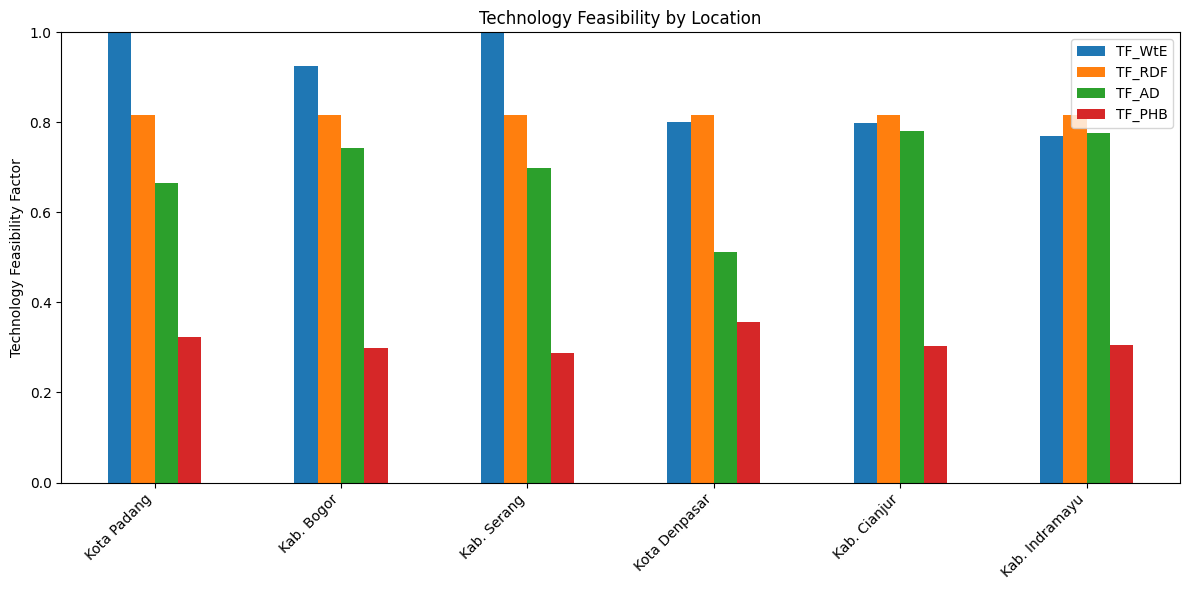

In [30]:
# ============================================================
# TECHNOLOGY FEASIBILITY VISUALISATION
# ============================================================

plot_df = (
    df_results[
        [
            "city_name",
            "TF_WtE",
            "TF_RDF",
            "TF_AD",
            "TF_PHB"
        ]
    ]
    .set_index(
        "city_name"
    )
)

ax = plot_df.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_ylabel(
    "Technology Feasibility Factor"
)

ax.set_xlabel(
    ""
)

ax.set_ylim(
    0,
    1
)

ax.set_title(
    "Technology Feasibility by Location"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [31]:
# ============================================================
# EXPORT COMPLETE RESULTS
# ============================================================

output_file = (
    "MSW_LCA_TEA_TF_results.xlsx"
)

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    composition_df.to_excel(
        writer,
        sheet_name="Composition",
        index=False
    )

    df_results.to_excel(
        writer,
        sheet_name="Deterministic",
        index=False
    )

    df_uncertainty.to_excel(
        writer,
        sheet_name="Monte_Carlo",
        index=False
    )

    df_best_probability.to_excel(
        writer,
        sheet_name="P_Best",
        index=False
    )

    df_class.to_excel(
        writer,
        sheet_name="Admin_Class",
        index=False
    )

    df_sensitivity.to_excel(
        writer,
        sheet_name="Sensitivity",
        index=False
    )


print(
    f"Complete results saved to: {output_file}"
)

Complete results saved to: MSW_LCA_TEA_TF_results.xlsx


In [32]:
# ============================================================
# CELL 27
# PARETO FRONT FUNCTIONS
# ============================================================

def pareto_front(values):
    """
    Identify non-dominated alternatives.

    Parameters
    ----------
    values : array, shape (n_alternatives, n_objectives)
        All objectives must be formulated as MAXIMIZE.

    Returns
    -------
    boolean array
        True = alternative belongs to Pareto front.
    """

    values = np.asarray(values, dtype=float)

    n = values.shape[0]

    efficient = np.ones(
        n,
        dtype=bool
    )

    for i in range(n):

        for j in range(n):

            if i == j:
                continue

            # j dominates i if:
            # j >= i in every objective
            # AND j > i in at least one objective

            dominates = (
                np.all(values[j] >= values[i])
                and
                np.any(values[j] > values[i])
            )

            if dominates:

                efficient[i] = False
                break

    return efficient

In [33]:
# ============================================================
# CELL 28
# DETERMINISTIC PARETO FRONT BY CITY
# ============================================================

pareto_rows = []

for i, r in df_input.iterrows():

    city = r.city_name

    s = S_composition[i]

    Q = float(
        r.M_total_tpd
    )

    # -------------------------
    # LCA + TEA
    # -------------------------

    G0, out, ch = evaluate(

        s[None, :],

        w_moisture[None, :],

        np.array([Q])
    )

    # -------------------------
    # Technology feasibility
    # -------------------------

    TF = technology_factor(

        s[None, :],

        w_moisture[None, :],

        np.array([Q]),

        ncv=ch["NCV"]
    )

    # -------------------------
    # Objective matrix
    #
    # all objectives MAXIMIZE
    # -------------------------

    objective_matrix = np.array([

        [
            out[k]["dGWP"][0],
            out[k]["NPV"][0],
            TF[k][0]
        ]

        for k in (1,2,3,4)
    ])

    is_pareto = pareto_front(
        objective_matrix
    )

    for j, k in enumerate(
        (1,2,3,4)
    ):

        pareto_rows.append({

            "city_name":
                city,

            "pathway":
                PATHWAYS[k],

            "dGWP":
                out[k]["dGWP"][0],

            "NPV_MUSD":
                out[k]["NPV"][0],

            "TF":
                TF[k][0],

            "Pareto":
                is_pareto[j]
        })


df_pareto = pd.DataFrame(
    pareto_rows
)

display(
    df_pareto.round(3)
)

,city_name,pathway,dGWP,NPV_MUSD,TF,Pareto
0,Kota Padang,WtE,1022.656,60.905,1.000,True
1,Kota Padang,RDF,579.386,-24.804,0.816,False
2,Kota Padang,AD,575.216,-10.907,0.665,False
3,Kota Padang,PHB,818.360,14.627,0.323,False
4,Kab. Bogor,WtE,913.084,370.080,0.926,True
5,Kab. Bogor,RDF,446.042,-109.105,0.816,False
6,Kab. Bogor,AD,718.744,-13.701,0.744,False
7,Kab. Bogor,PHB,719.396,41.895,0.299,False
8,Kab. Serang,WtE,740.612,166.235,1.000,True
9,Kab. Serang,RDF,419.479,-43.538,0.816,False


In [34]:
# ============================================================
# CELL 29
# PARETO-EFFICIENT PATHWAYS
# ============================================================

df_pareto_front = (

    df_pareto[
        df_pareto["Pareto"]
    ]

    .copy()

    .sort_values([
        "city_name",
        "dGWP"
    ])
)

display(
    df_pareto_front.round(3)
)

,city_name,pathway,dGWP,NPV_MUSD,TF,Pareto
4,Kab. Bogor,WtE,913.084,370.080,0.926,True
17,Kab. Cianjur,RDF,407.459,-45.673,0.816,True
16,Kab. Cianjur,WtE,963.439,90.800,0.799,True
21,Kab. Indramayu,RDF,434.438,-47.632,0.816,True
22,Kab. Indramayu,AD,782.663,0.131,0.776,True
20,Kab. Indramayu,WtE,986.543,94.882,0.769,True
8,Kab. Serang,WtE,740.612,166.235,1.000,True
13,Kota Denpasar,RDF,707.161,-36.259,0.816,True
12,Kota Denpasar,WtE,1353.046,75.780,0.801,True
0,Kota Padang,WtE,1022.656,60.905,1.000,True


In [35]:
# ============================================================
# CELL 30
# PROBABILISTIC PARETO ROBUSTNESS
# ============================================================

def probabilistic_pareto(mc):

    N = len(
        mc["out"][1]["NPV"]
    )

    pathways = [
        1,2,3,4
    ]

    counts = np.zeros(
        4
    )

    for m in range(N):

        objectives = np.array([

            [
                mc["out"][k]["dGWP"][m],
                mc["out"][k]["NPV"][m],
                mc["TF"][k][m]
            ]

            for k in pathways
        ])

        pf = pareto_front(
            objectives
        )

        counts += pf.astype(int)

    return (
        counts / N
    )

In [36]:
# ============================================================
# CELL 31
# MONTE CARLO PARETO PROBABILITY BY CITY
# ============================================================

pareto_probability_rows = []

for city, mc in mc_city_results.items():

    probability = (
        probabilistic_pareto(mc)
    )

    row = {
        "city_name": city
    }

    for j, k in enumerate(
        (1,2,3,4)
    ):

        row[
            f"P_Pareto_{PATHWAYS[k]}"
        ] = probability[j]

    pareto_probability_rows.append(
        row
    )


df_pareto_probability = (
    pd.DataFrame(
        pareto_probability_rows
    )
)

display(
    df_pareto_probability.round(3)
)

,city_name,P_Pareto_WtE,P_Pareto_RDF,P_Pareto_AD,P_Pareto_PHB
0,Kota Padang,1.0,0.060,0.019,0.018
1,Kab. Bogor,1.0,0.316,0.291,0.006
2,Kab. Serang,1.0,0.018,0.212,0.201
3,Kota Denpasar,1.0,0.565,0.075,0.047
4,Kab. Cianjur,1.0,0.411,0.540,0.009
5,Kab. Indramayu,1.0,0.494,0.556,0.009
